In [13]:
import librosa
import librosa.feature
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

In [14]:
# Loading sample audio file
audio_path = 'yes_sample.wav'
audio, sr = librosa.load(audio_path, sr=None) #sr takes 22050 (default value)

print("Sampling Rate:", sr)
print("Length:", len(audio))
print(f'Duration: {len(audio)/sr} s')

Sampling Rate: 16000
Length: 16000
Duration: 1.0 s


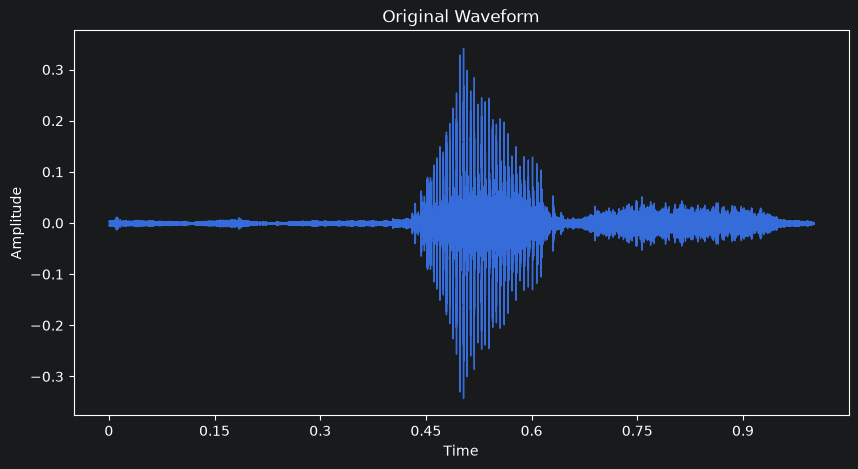

In [15]:
# Plotting the waveform (Time domain)
plt.figure(figsize=(10,5))
librosa.display.waveshow(audio, sr=sr)

plt.title("Original Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

Index: [    0 10000]


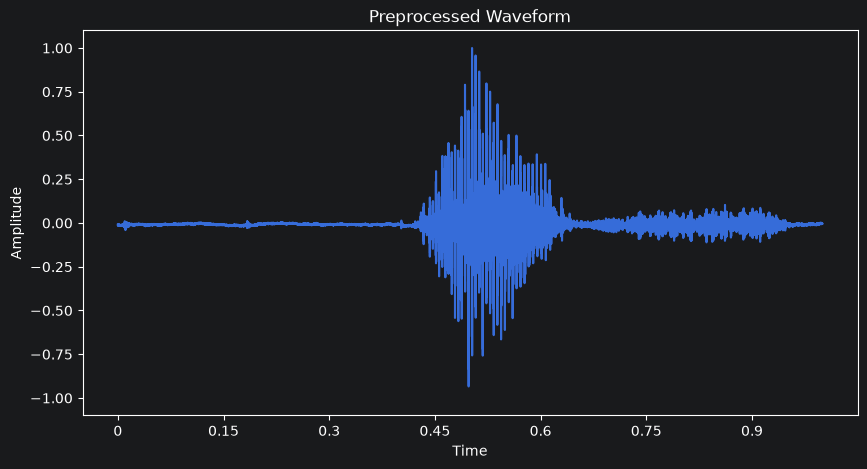

In [16]:
# Preprocessing - Resampling,Normalizing and Trimming
new_sr = 10000
resample_audio = librosa.resample(audio, orig_sr=sr, target_sr= new_sr)

norm_audio = librosa.util.normalize(resample_audio)

trim_audio, idx = librosa.effects.trim(norm_audio)
print(f'Index: {idx}')
plt.figure(figsize=(10,5))
librosa.display.waveshow(trim_audio,sr=new_sr)

plt.title("Preprocessed Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

The above waveform is normalized between -1 to 1

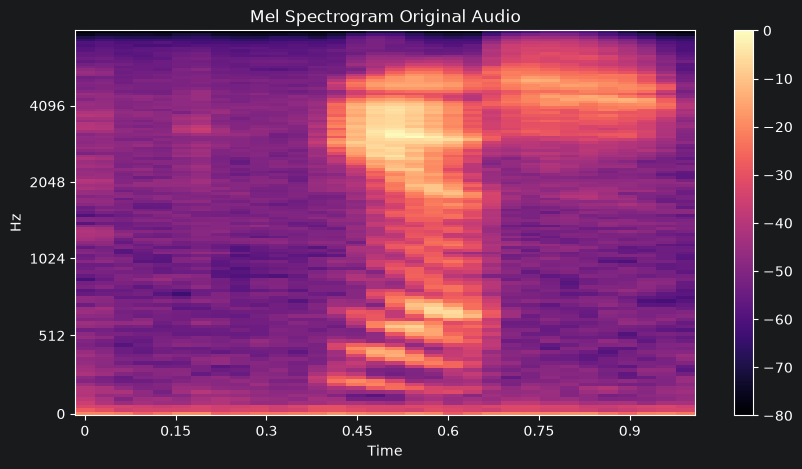

In [18]:
# Mel spectrogram

mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title('Mel Spectrogram Original Audio')
plt.show()

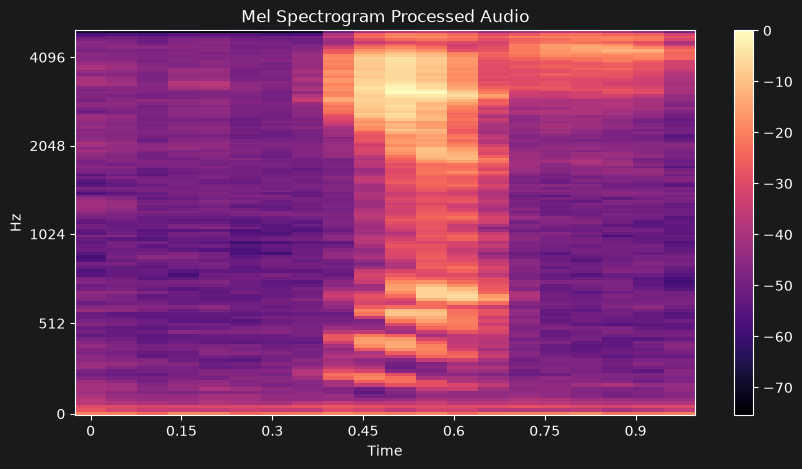

In [19]:
mel_spec_processed = librosa.feature.melspectrogram(y=trim_audio, sr=new_sr)

mel_spec_processed_db = librosa.power_to_db(mel_spec_processed, ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(mel_spec_processed_db, sr=new_sr, x_axis='time', y_axis='mel')

plt.colorbar()
plt.title('Mel Spectrogram Processed Audio')
plt.show()

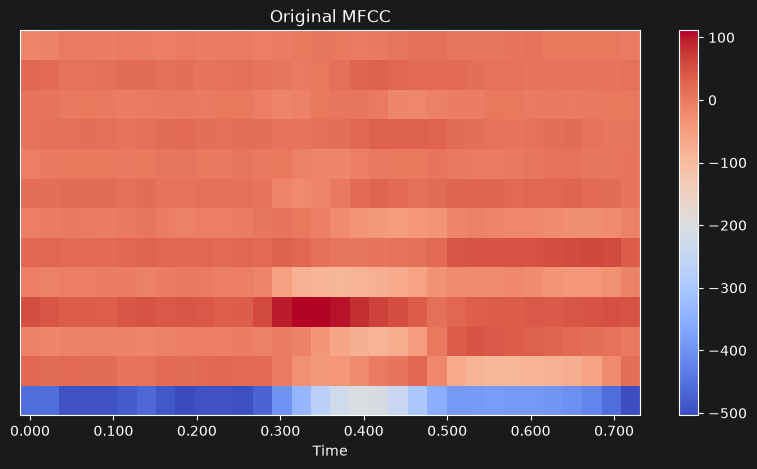

In [20]:
# MFCC HeatMap
mfcc_og = librosa.feature.mfcc(y=audio,sr=sr,n_mfcc=13)
plt.figure(figsize=(10,5))
librosa.display.specshow(mfcc_og,x_axis='time')

plt.colorbar()
plt.title("Original MFCC")
plt.show()

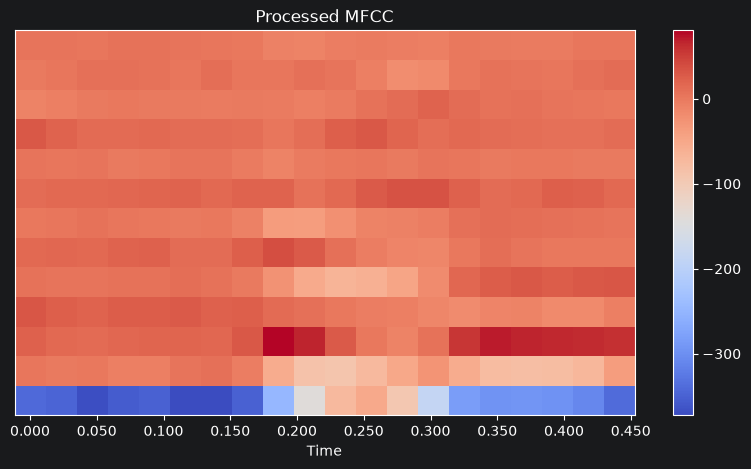

In [22]:
mfcc_process = librosa.feature.mfcc(y=trim_audio,sr=new_sr,n_mfcc=13)
plt.figure(figsize=(10,5))
librosa.display.specshow(mfcc_process,x_axis='time')

plt.colorbar()
plt.title("Processed MFCC")
plt.show()

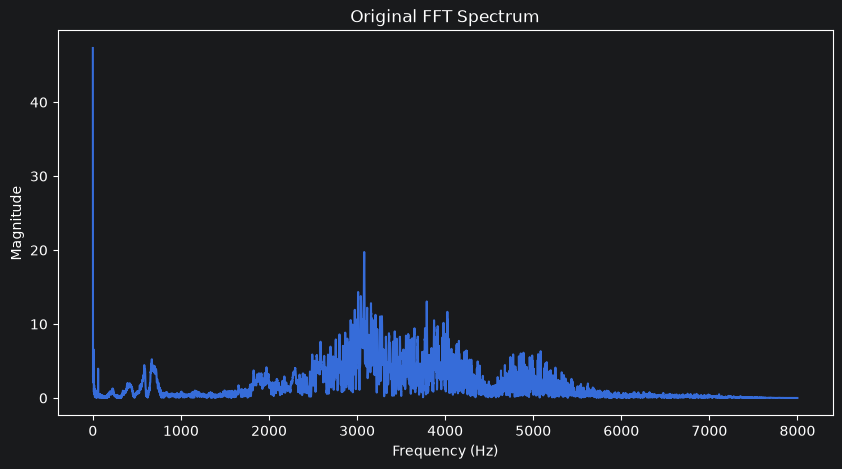

In [23]:
# FFT Spectrum of original audio

N = len(audio)
yf = fft(audio)
xf = fftfreq(N, 1/sr)

plt.figure(figsize=(10,5))
plt.plot(xf[:N//2], np.abs(yf[:N//2]))

plt.title("Original FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

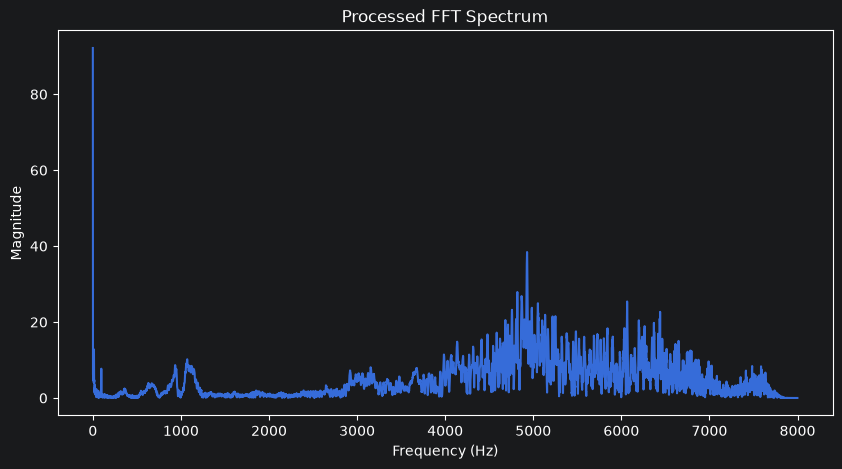

In [24]:
# FFT Spectrum of processed audio

N = len(trim_audio)
yf = fft(trim_audio)
xf = fftfreq(N, 1/sr)

plt.figure(figsize=(10,5))
plt.plot(xf[:N//2], np.abs(yf[:N//2]))

plt.title("Processed FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

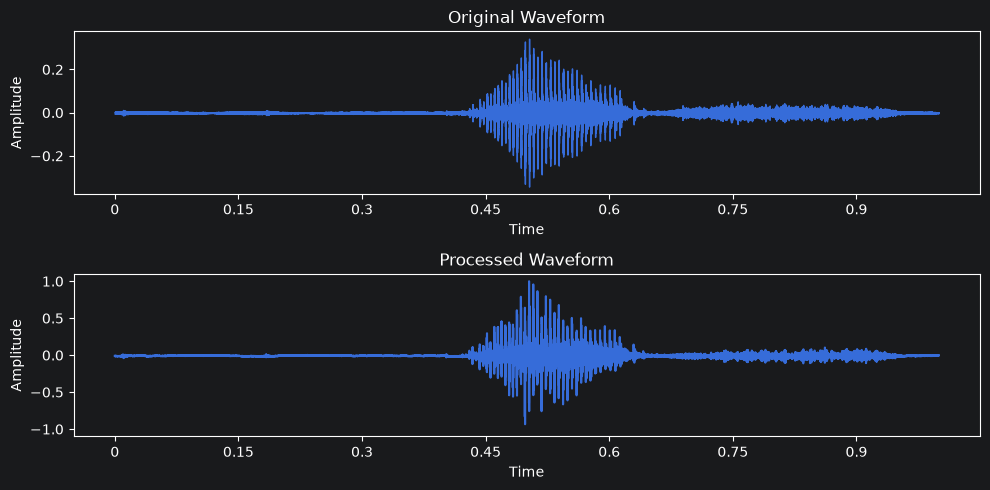

In [25]:
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
librosa.display.waveshow(audio,sr=sr)
plt.title("Original Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(2,1,2)
librosa.display.waveshow(trim_audio,sr=new_sr)
plt.title("Processed Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()